# LTAF Database — Pipeline de Detecção de Arritmia

Dataset: PhysioNet `ltafdb/1.0.0` — 84 gravações Holter 24h, 2 canais ECG, 128 Hz, 12-bit.

**Pipeline em 3 estágios:**
1. **Segmentação adaptativa** — detecção de onset/offset por derivada do sinal
2. **CNN de morfologia** — classifica cada batimento em N / A / V
3. **BiLSTM de ritmo** — classifica janelas de 10s em Normal vs Anormal

## 1 — Setup

In [2]:
import sys
import subprocess

subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-r', 'requirements.txt'
])

: 

: 

## 2 — Imports e Configurações

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import os
import pickle
import random

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import butter, filtfilt, savgol_filter
from scipy.interpolate import interp1d

from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Reprodutibilidade básica
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# Filtro passa-banda
def bandpass(sig, fs, low=0.5, high=40):
    b, a = butter(3, [low / (fs / 2), high / (fs / 2)], btype='band')
    return filtfilt(b, a, sig)


## 3 — Carregamento do Sinal e Anotações

In [2]:
# Carregamento automático de todos os registros disponíveis em data/
from IPython.display import display, Markdown

DATA_DIR = Path("data")
MAX_PATIENTS = 10

def find_available_records(data_dir):
    """
    Retorna todos os registros que possuem .hea, .dat e .atr.
    Exemplo: data/22.hea + data/22.dat + data/22.atr -> "22"
    """
    records = []
    for hea_file in sorted(data_dir.glob("*.hea")):
        rec_id = hea_file.stem
        if (data_dir / f"{rec_id}.dat").exists() and (data_dir / f"{rec_id}.atr").exists():
            records.append(rec_id)
    return records

RECORDS_ALL = find_available_records(DATA_DIR)

if len(RECORDS_ALL) == 0:
    raise FileNotFoundError(
        "Nenhum registro com .hea, .dat e .atr foi encontrado na pasta data/."
    )

# Limita o número máximo de pacientes/registros usados no experimento.
RECORDS = RECORDS_ALL[:MAX_PATIENTS]

display(Markdown("## Carregamento automático dos registros"))
display(Markdown(f"**Registros encontrados na pasta:** `{len(RECORDS_ALL)}`"))
display(Markdown(f"**Máximo de pacientes configurado:** `{MAX_PATIENTS}`"))
display(Markdown(f"**Registros selecionados para uso:** `{len(RECORDS)}`"))
display(Markdown(f"**Lista de registros usados:** `{', '.join(RECORDS)}`"))

records_data = {}
dfs = []
failed_records = []
load_summary = []

for rec_id in RECORDS:
    try:
        record_path = DATA_DIR / rec_id
        record = wfdb.rdrecord(str(record_path))
        ann = wfdb.rdann(str(record_path), "atr")

        signal = record.p_signal[:, 0]
        fs = record.fs
        duration_hours = len(signal) / fs / 3600

        df_rec = pd.DataFrame({
            "record_id": rec_id,
            "sample": ann.sample,
            "time_seconds": ann.sample / fs,
            "time": [
                f"{int(x//3600):02d}:{int((x%3600)//60):02d}:{x%60:05.2f}"
                for x in ann.sample / fs
            ],
            "symbol": ann.symbol,
            "aux_note": ann.aux_note,
            "fs": fs,
        })

        df_rec["rhythm"] = df_rec["aux_note"].replace("", None).ffill()

        records_data[rec_id] = {
            "signal": signal,
            "fs": fs,
            "n_samples": len(signal),
            "duration_hours": duration_hours,
        }

        dfs.append(df_rec)

        load_summary.append({
            "record_id": rec_id,
            "status": "OK",
            "fs_hz": fs,
            "samples": len(signal),
            "duration_h": round(duration_hours, 2),
            "annotations": len(df_rec),
            "unique_symbols": df_rec["symbol"].nunique(),
            "unique_rhythms": df_rec["rhythm"].nunique(dropna=True),
        })

    except Exception as e:
        failed_records.append(rec_id)

        load_summary.append({
            "record_id": rec_id,
            "status": "FALHA",
            "fs_hz": None,
            "samples": None,
            "duration_h": None,
            "annotations": None,
            "unique_symbols": None,
            "unique_rhythms": None,
            "error": str(e),
        })

if len(dfs) == 0:
    raise RuntimeError("Nenhum registro foi carregado com sucesso.")

df = pd.concat(dfs, ignore_index=True)

summary_df = pd.DataFrame(load_summary)

display(Markdown("### Resumo por registro"))
display(summary_df)

display(Markdown("### Resumo geral"))

general_summary = pd.DataFrame({
    "métrica": [
        "Registros encontrados na pasta",
        "Máximo de pacientes configurado",
        "Registros selecionados para uso",
        "Registros carregados com sucesso",
        "Registros com falha",
        "Total de amostras",
        "Duração total aproximada (h)",
        "Total de anotações",
        "Símbolos distintos",
        "Ritmos distintos",
    ],
    "valor": [
        len(RECORDS_ALL),
        MAX_PATIENTS,
        len(RECORDS),
        df["record_id"].nunique(),
        len(failed_records),
        sum(v["n_samples"] for v in records_data.values()),
        round(sum(v["duration_hours"] for v in records_data.values()), 2),
        len(df),
        df["symbol"].nunique(),
        df["rhythm"].nunique(dropna=True),
    ]
})

display(general_summary)

if failed_records:
    display(Markdown("### Registros com falha"))
    display(summary_df[summary_df["status"] == "FALHA"])

display(Markdown("### Distribuição dos símbolos de batimento"))
display(
    df["symbol"]
    .value_counts()
    .rename_axis("symbol")
    .reset_index(name="count")
    .head(30)
)

display(Markdown("### Ritmos presentes"))
display(
    df["rhythm"]
    .value_counts(dropna=False)
    .rename_axis("rhythm")
    .reset_index(name="count")
    .head(30)
)

display(Markdown("### Primeiras anotações carregadas"))
display(df.head())

## Carregamento automático dos registros

**Registros encontrados na pasta:** `84`

**Máximo de pacientes configurado:** `10`

**Registros selecionados para uso:** `10`

**Lista de registros usados:** `00, 01, 03, 05, 06, 07, 08, 10, 100, 101`

...

,symbol,count
0,N,966102
1,A,27781
2,V,14501
3,+,8875
4,"""",228
5,Q,8


### Ritmos presentes

,rhythm,count
0,(N,577678
1,(AFIB,157444
2, Aux,148555
3,MISSB,63676
4,PSE,32163
5,(SBR,24770
6,(B,5379
7,(AB,5090
8,(SVTA,1784
9,(T,775


### Primeiras anotações carregadas

,record_id,sample,time_seconds,time,symbol,aux_note,fs,rhythm
0,00,83607,653.179688,00:10:53.18,+,(N,128,(N
1,00,83628,653.343750,00:10:53.34,N,,128,(N
2,00,83736,654.187500,00:10:54.19,N,,128,(N
3,00,83844,655.031250,00:10:55.03,N,,128,(N
4,00,83953,655.882812,00:10:55.88,N,,128,(N


## 4 — Estágio 1: Segmentação Adaptativa

Usando os samples do `.atr` como âncoras (picos QRS), detecta onset e offset de cada onda via derivada suavizada (Savitzky-Golay). Interpolação cúbica para tamanho fixo de 200 amostras (~1.56s a 128Hz).

**Label: N = 0, A = 1, V = 2** (morfologia por batimento)
**Normal:** `symbol == 'N'` AND `rhythm == '(N'`

In [3]:
# Picos QRS a partir do .atr (apenas batimentos anotados)
BEAT_SYMBOLS = ["N", "A", "V"]

beats_all = (
    df[df["symbol"].isin(BEAT_SYMBOLS)]
    .copy()
    .sort_values(["record_id", "sample"])
    .reset_index(drop=True)
)

print(f"Total de batimentos N/A/V: {len(beats_all)}")
print("Distribuição por classe:")
print(beats_all["symbol"].value_counts())
print("\nBatimentos por registro:")
print(beats_all.groupby("record_id").size().describe())


Total de batimentos N/A/V: 1008384
Distribuição por classe:
symbol
N    966102
A     27781
V     14501
Name: count, dtype: int64

Batimentos por registro:
count        10.000000
mean     100838.400000
std       10195.917573
min       80957.000000
25%       93111.500000
50%      105455.000000
75%      107872.500000
max      112922.000000
dtype: float64


In [4]:
def detect_wave_bounds(sig, peak, fs, search_pre=0.25, search_post=0.40, smooth_window=11):
    """Retorna (onset, offset) em índices de amostra via derivada suavizada."""
    pre  = int(search_pre * fs)
    post = int(search_post * fs)
    left  = max(0, peak - pre)
    right = min(len(sig) - 1, peak + post)
    seg = sig[left:right]
    if len(seg) < smooth_window + 2:
        return left, right
    dseg = savgol_filter(seg, smooth_window, 2, deriv=1)
    peak_local = peak - left
    left_deriv   = np.abs(dseg[:peak_local])
    onset_local  = np.argmin(left_deriv) if len(left_deriv) > 0 else 0
    right_deriv  = np.abs(dseg[peak_local:])
    offset_local = peak_local + (np.argmin(right_deriv) if len(right_deriv) > 0 else 0)
    return left + onset_local, left + offset_local

In [5]:
TARGET_LEN = 200  # amostras fixas por segmento

segments = []
segment_records = []

for rec_id, group in beats_all.groupby("record_id"):
    signal = records_data[rec_id]["signal"]
    fs = records_data[rec_id]["fs"]

    for _, row in group.iterrows():
        peak = int(row["sample"])
        onset, offset = detect_wave_bounds(signal, peak, fs)
        seg = signal[onset:offset]

        if len(seg) < 10:
            continue

        x_orig = np.linspace(0, 1, len(seg))
        x_new = np.linspace(0, 1, TARGET_LEN)
        seg_resampled = interp1d(x_orig, seg, kind="cubic")(x_new)

        segments.append(seg_resampled)
        segment_records.append({
            "record_id": rec_id,
            "sample": peak,
            "time_seconds": row["time_seconds"],
            "symbol": row["symbol"],
            "rhythm": row["rhythm"],
            "fs": fs,
        })

segments = np.array(segments)
seg_df = pd.DataFrame(segment_records)

# Compatibilidade com células de visualização antigas
seg_peaks = seg_df["sample"].values

print(f"Segmentos extraídos: {segments.shape}")
print(f"Registros com segmentos: {seg_df['record_id'].nunique()}")
seg_df.head()


Segmentos extraídos: (1005174, 200)
Registros com segmentos: 10


,record_id,sample,time_seconds,symbol,rhythm,fs
0,00,83628,653.343750,N,(N,128
1,00,83736,654.187500,N,(N,128
2,00,83844,655.031250,N,(N,128
3,00,83953,655.882812,N,(N,128
4,00,84062,656.734375,N,(N,128


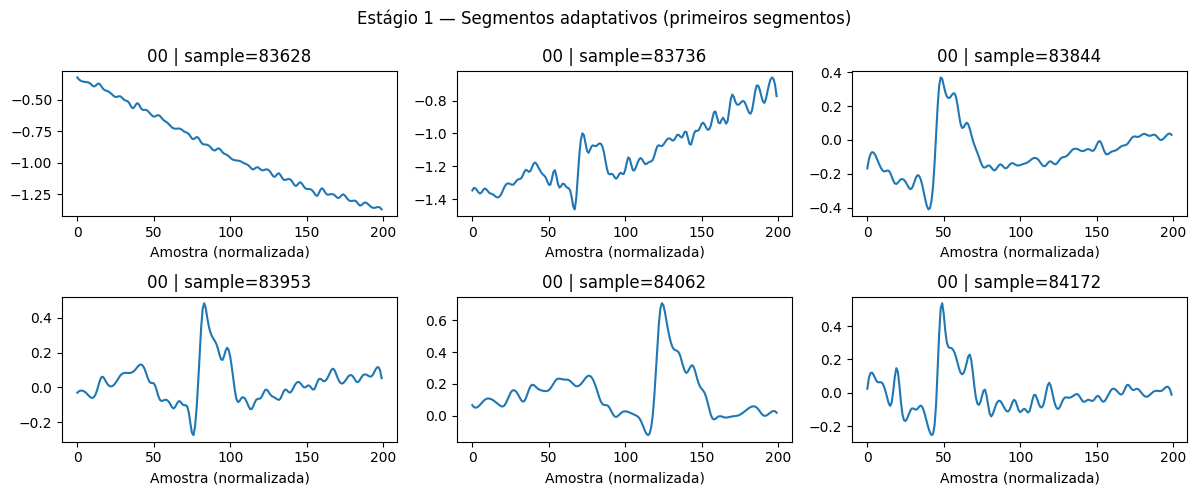

In [6]:
# Verificação visual — primeiros 6 segmentos
n_plot = min(6, len(segments))
fig, axes = plt.subplots(2, 3, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    if i >= n_plot:
        ax.axis("off")
        continue
    ax.plot(segments[i])
    ax.set_title(f"{seg_df.iloc[i]['record_id']} | sample={seg_df.iloc[i]['sample']}")
    ax.set_xlabel("Amostra (normalizada)")
plt.suptitle("Estágio 1 — Segmentos adaptativos (primeiros segmentos)")
plt.tight_layout()
plt.show()


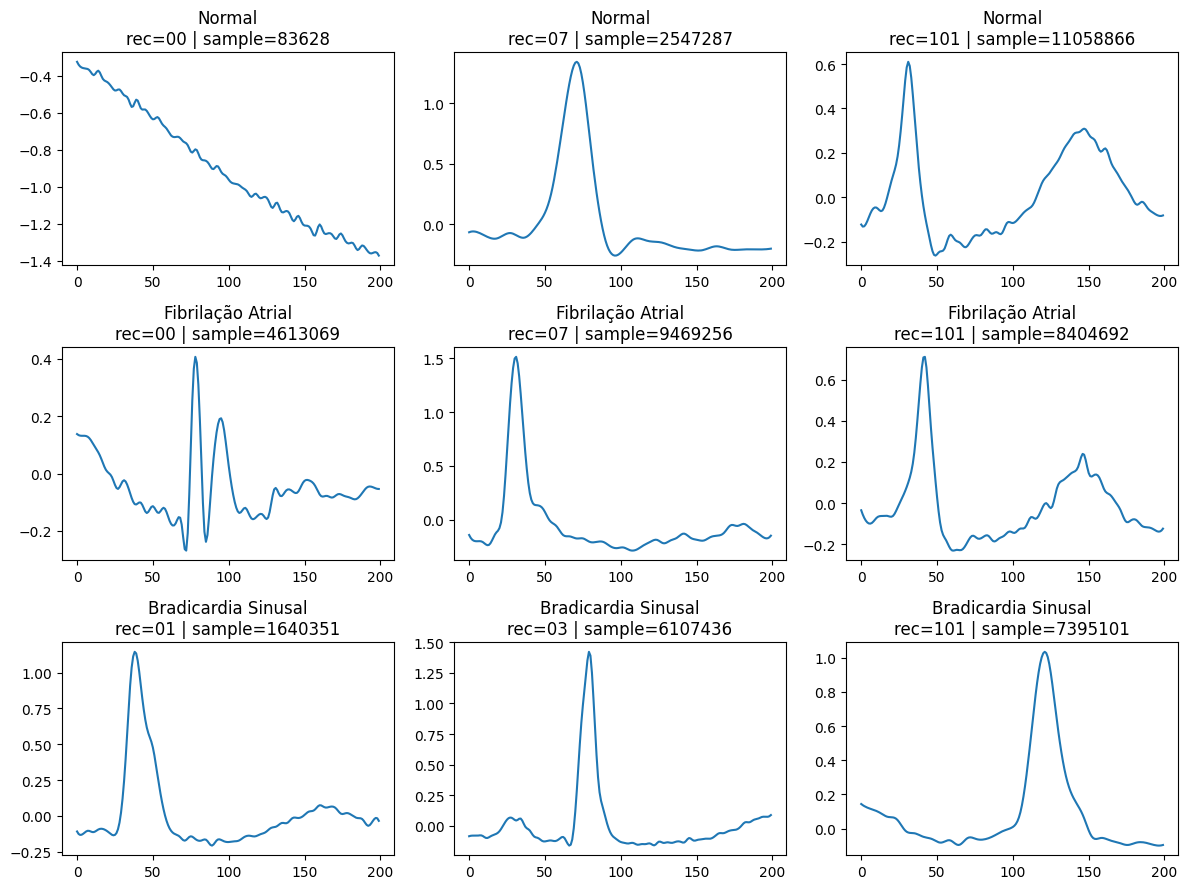

In [7]:
# Verificação por ritmo — Normal, AFIB, Bradicardia
def plot_rhythm_comparison(seg_df, segments):
    ritmos = {"(N": "Normal", "(AFIB": "Fibrilação Atrial", "(SBR": "Bradicardia Sinusal"}
    fig, axes = plt.subplots(len(ritmos), 3, figsize=(12, 9))

    for row, (ritmo, label) in enumerate(ritmos.items()):
        idxs_available = seg_df.index[seg_df["rhythm"] == ritmo].to_numpy()

        if len(idxs_available) == 0:
            for col in range(3):
                axes[row, col].axis("off")
            continue

        idxs = np.linspace(0, len(idxs_available) - 1, min(3, len(idxs_available)), dtype=int)

        for col in range(3):
            if col >= len(idxs):
                axes[row, col].axis("off")
                continue

            seg_idx = idxs_available[idxs[col]]
            axes[row, col].plot(segments[seg_idx])
            axes[row, col].set_title(
                f"{label}\nrec={seg_df.loc[seg_idx, 'record_id']} | sample={seg_df.loc[seg_idx, 'sample']}"
            )

    plt.tight_layout()
    plt.show()

plot_rhythm_comparison(seg_df, segments)


## 5 — Estágio 2: CNN de Morfologia (N / A / V)

CNN 1D com 3 blocos Conv+BN+MaxPool → GlobalAveragePooling → Dense(64) → Dropout(0.5) → Softmax(3).

Input: segmentos de 200 amostras (saída do Estágio 1), filtrados e normalizados por batimento.
Split: 80% treino → SMOTE → 20% validação (sem SMOTE) | 20% teste (sem SMOTE).

In [8]:
# Dados do Estágio 2: CNN de morfologia
# Cada segmento já possui record_id, símbolo real, ritmo e fs em seg_df.
X2 = segments.copy()
y2 = seg_df["symbol"].values

# Filtro e normalização por batimento
X2 = np.array([
    bandpass(x, fs=row_fs)
    for x, row_fs in zip(X2, seg_df["fs"].values)
])
X2 = (X2 - X2.mean(axis=1, keepdims=True)) / (X2.std(axis=1, keepdims=True) + 1e-8)

le2 = LabelEncoder()
y2_enc = le2.fit_transform(y2)

print(f"Shape: {X2.shape}")
print(f"Classes: {le2.classes_}")
print(f"Distribuição: {dict(zip(le2.classes_, np.bincount(y2_enc)))}")


Shape: (1005174, 200)
Classes: ['A' 'N' 'V']
Distribuição: {'A': np.int64(27732), 'N': np.int64(963095), 'V': np.int64(14347)}


In [9]:
# Split por registro/paciente, evitando misturar o mesmo paciente entre treino e teste
unique_records = np.array(sorted(seg_df["record_id"].unique()))

if len(unique_records) >= 3:
    train_records, test_records = train_test_split(
        unique_records,
        test_size=0.20,
        random_state=SEED
    )

    if len(train_records) >= 2:
        train_records, val_records = train_test_split(
            train_records,
            test_size=0.20,
            random_state=SEED
        )
    else:
        val_records = test_records

    train_mask = seg_df["record_id"].isin(train_records).values
    val_mask = seg_df["record_id"].isin(val_records).values
    test_mask = seg_df["record_id"].isin(test_records).values

    split_mode = "record-level"

else:
    # Fallback para não quebrar quando só existe um registro em data/.
    # Para resultado científico, use vários registros e evite este modo.
    idx = np.arange(len(X2))
    idx_train, idx_test = train_test_split(
        idx,
        test_size=0.20,
        random_state=SEED,
        stratify=y2_enc
    )
    idx_train, idx_val = train_test_split(
        idx_train,
        test_size=0.20,
        random_state=SEED,
        stratify=y2_enc[idx_train]
    )

    train_mask = np.zeros(len(X2), dtype=bool); train_mask[idx_train] = True
    val_mask = np.zeros(len(X2), dtype=bool); val_mask[idx_val] = True
    test_mask = np.zeros(len(X2), dtype=bool); test_mask[idx_test] = True

    train_records = seg_df.loc[train_mask, "record_id"].unique()
    val_records = seg_df.loc[val_mask, "record_id"].unique()
    test_records = seg_df.loc[test_mask, "record_id"].unique()

    split_mode = "beat-level fallback"

X2_train = X2[train_mask].reshape(-1, TARGET_LEN, 1)
X2_val = X2[val_mask].reshape(-1, TARGET_LEN, 1)
X2_test = X2[test_mask].reshape(-1, TARGET_LEN, 1)

y2_train = y2_enc[train_mask]
y2_val = y2_enc[val_mask]
y2_test = y2_enc[test_mask]

# Pesos de classe no lugar de SMOTE para evitar gerar batimentos artificiais
class_values = np.unique(y2_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=class_values,
    y=y2_train
)
class_weight2 = dict(zip(class_values, weights))

print(f"Modo de split: {split_mode}")
print(f"Train records ({len(train_records)}): {sorted(train_records)}")
print(f"Val records   ({len(val_records)}): {sorted(val_records)}")
print(f"Test records  ({len(test_records)}): {sorted(test_records)}")

print(f"\nTreino: {X2_train.shape}, Val: {X2_val.shape}, Teste: {X2_test.shape}")
print(f"Dist treino: {np.bincount(y2_train, minlength=len(le2.classes_))}")
print(f"Dist val:    {np.bincount(y2_val, minlength=len(le2.classes_))}")
print(f"Dist teste:  {np.bincount(y2_test, minlength=len(le2.classes_))}")
print(f"Class weights: {class_weight2}")


Modo de split: record-level
Train records (6): [np.str_('03'), np.str_('05'), np.str_('07'), np.str_('08'), np.str_('10'), np.str_('101')]
Val records   (2): [np.str_('00'), np.str_('06')]
Test records  (2): [np.str_('01'), np.str_('100')]

Treino: (614115, 200, 1), Val: (210401, 200, 1), Teste: (180658, 200, 1)
Dist treino: [ 12133 591700  10282]
Dist val:    [  4555 205063    783]
Dist teste:  [ 11044 166332   3282]
Class weights: {np.int64(0): np.float64(16.871754718536224), np.int64(1): np.float64(0.3459607909413554), np.int64(2): np.float64(19.90906438436102)}


In [10]:
model2 = models.Sequential([
    layers.Input(shape=(200, 1)),
    layers.Conv1D(32, kernel_size=5, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),
    layers.Conv1D(64, kernel_size=5, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),
    layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])

model2.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 200, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,547 (174.01 KB)

 Trainable params: 44,099 (172.26 KB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
callbacks2 = [
    EarlyStopping(patience=10, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.5)
]

history2 = model2.fit(
    X2_train, y2_train,
    epochs=30,
    batch_size=64,
    validation_data=(X2_val, y2_val),
    callbacks=callbacks2,
    class_weight=class_weight2
)


Epoch 1/30
9596/9596 ━━━━━━━━━━━━━━━━━━━━ 162s 17ms/step - accuracy: 0.7256 - loss: 0.4944 - val_accuracy: 0.5286 - val_loss: 1.5490 - learning_rate: 0.0010
Epoch 2/30
9596/9596 ━━━━━━━━━━━━━━━━━━━━ 172s 18ms/step - accuracy: 0.7683 - loss: 0.4093 - val_accuracy: 0.7121 - val_loss: 0.9017 - learning_rate: 0.0010
Epoch 3/30
9596/9596 ━━━━━━━━━━━━━━━━━━━━ 172s 18ms/step - accuracy: 0.7803 - loss: 0.3837 - val_accuracy: 0.5757 - val_loss: 1.3283 - learning_rate: 0.0010
Epoch 4/30
9596/9596 ━━━━━━━━━━━━━━━━━━━━ 180s 19ms/step - accuracy: 0.7894 - loss: 0.3652 - val_accuracy: 0.6416 - val_loss: 1.0354 - learning_rate: 0.0010
Epoch 5/30
9596/9596 ━━━━━━━━━━━━━━━━━━━━ 173s 18ms/step - accuracy: 0.7978 - loss: 0.3552 - val_accuracy: 0.6043 - val_loss: 1.1470 - learning_rate: 0.0010
Epoch 6/30
9596/9596 ━━━━━━━━━━━━━━━━━━━━ 180s 19ms/step - accuracy: 0.8117 - loss: 0.3255 - val_accuracy: 0.6440 - val_loss: 1.1667 - learning_rate: 5.0000e-04
Epoch 7/30
9596/9596 ━━━━━━━━━━━━━━━━━━━━ 178s 18ms/st

5646/5646 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step


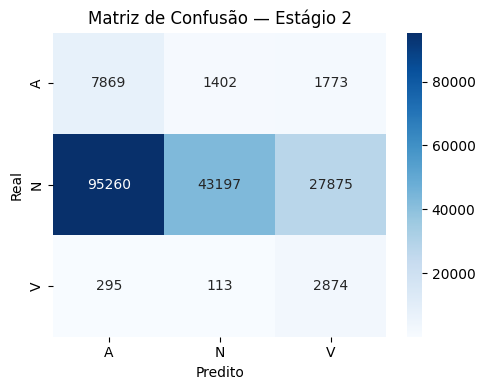

              precision    recall  f1-score   support

           A       0.08      0.71      0.14     11044
           N       0.97      0.26      0.41    166332
           V       0.09      0.88      0.16      3282

    accuracy                           0.30    180658
   macro avg       0.38      0.62      0.24    180658
weighted avg       0.90      0.30      0.39    180658

AUC A: 0.5532
AUC N: 0.5714
AUC V: 0.9244


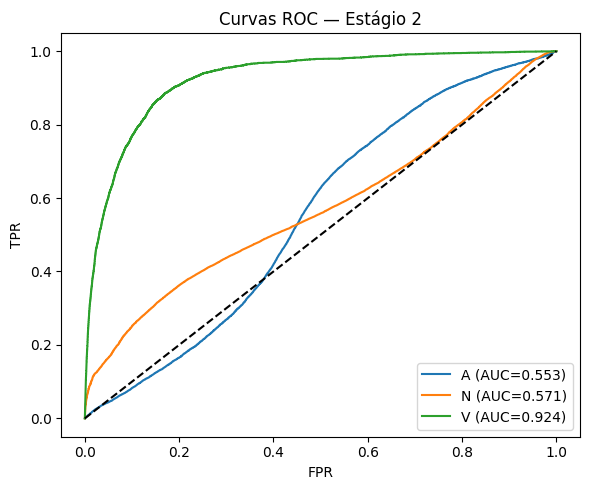

A → Sensitivity: 0.713 | Specificity: 0.437
N → Sensitivity: 0.260 | Specificity: 0.894
V → Sensitivity: 0.876 | Specificity: 0.833


In [12]:
# Avaliação — Estágio 2
y2_pred_proba = model2.predict(X2_test)
y2_pred = np.argmax(y2_pred_proba, axis=1)
classes = le2.classes_

# Confusion Matrix
cm2 = confusion_matrix(y2_test, y2_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm2, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
ax.set_xlabel('Predito'); ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão — Estágio 2')
plt.tight_layout(); plt.show()

print(classification_report(y2_test, y2_pred, target_names=classes))

# AUC
y2_test_bin = label_binarize(y2_test, classes=[0, 1, 2])
auc2_scores = roc_auc_score(y2_test_bin, y2_pred_proba, average=None)
for c, auc in zip(classes, auc2_scores):
    print(f"AUC {c}: {auc:.4f}")

# Curvas ROC
fig, ax = plt.subplots(figsize=(6, 5))
for i, c in enumerate(classes):
    fpr, tpr, _ = roc_curve(y2_test_bin[:, i], y2_pred_proba[:, i])
    ax.plot(fpr, tpr, label=f"{c} (AUC={auc2_scores[i]:.3f})")
ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Curvas ROC — Estágio 2')
ax.legend(); plt.tight_layout(); plt.show()

# Sensitivity / Specificity
for i, c in enumerate(classes):
    tp = cm2[i, i]; fn = cm2[i, :].sum() - tp
    fp = cm2[:, i].sum() - tp; tn = cm2.sum() - tp - fn - fp
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"{c} → Sensitivity: {sens:.3f} | Specificity: {spec:.3f}")

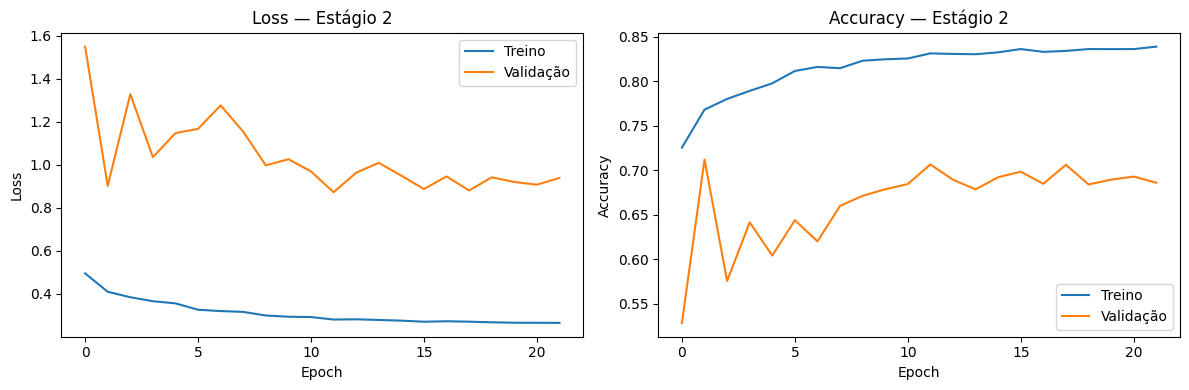

In [13]:
# Curvas de loss — Estágio 2
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history2.history['loss'], label='Treino')
axes[0].plot(history2.history['val_loss'], label='Validação')
axes[0].set_title('Loss — Estágio 2')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(history2.history['accuracy'], label='Treino')
axes[1].plot(history2.history['val_accuracy'], label='Validação')
axes[1].set_title('Accuracy — Estágio 2')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout(); plt.show()

## 6 — Estágio 3: BiLSTM de Ritmo (Normal vs Anormal)

Janelas de 10s. Cada janela contém uma sequência de batimentos com 2 features: `[pred_symbol, rr_interval]`.

- `pred_symbol`: label do Estágio 2 (N=0, A=1, V=2)
- `rr`: intervalo entre batimentos em segundos (normalizado)

**Label da janela:** 0 = Normal (`N + (N` em todos os batimentos), 1 = Anormal (qualquer outro)

Arquitetura: BiLSTM(64) → Dropout → BiLSTM(32) → Dropout → Dense(32) → Sigmoid(1)

In [14]:
# Predições do model2 sobre todos os segmentos
X2_all = X2.reshape(-1, TARGET_LEN, 1)

pred_labels_all = le2.inverse_transform(
    np.argmax(model2.predict(X2_all, batch_size=512), axis=1)
)

beats = seg_df.copy().reset_index(drop=True)
beats["pred_symbol"] = pred_labels_all

# Label real de normalidade por batimento:
# normal = símbolo N e ritmo normal; caso contrário, potencialmente anormal.
beats["label"] = ((beats["symbol"] == "N") & (beats["rhythm"] == "(N")).astype(int)

# RR e BPM por registro, sem cruzar pacientes
beats = beats.sort_values(["record_id", "sample"]).reset_index(drop=True)
beats["rr"] = beats.groupby("record_id")["sample"].diff() / beats["fs"]
beats["rr"] = beats["rr"].fillna(0.0)

# Evitar BPM infinito no primeiro batimento de cada registro
beats["bpm"] = np.where(beats["rr"] > 0, 60.0 / beats["rr"], np.nan)

WINDOW_SEC = 10
beats["window_id"] = (beats["time_seconds"] // WINDOW_SEC).astype(int)

print(beats[["record_id", "sample", "symbol", "pred_symbol", "rr", "bpm", "window_id"]].head())


1964/1964 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step
  record_id  sample symbol pred_symbol        rr        bpm  window_id
0        00   83628      N           N  0.000000        NaN         65
1        00   83736      N           N  0.843750  71.111111         65
2        00   83844      N           A  0.843750  71.111111         65
3        00   83953      N           V  0.851562  70.458716         65
4        00   84062      N           V  0.851562  70.458716         65


In [15]:
# Construção das janelas do Estágio 3 sem cruzar registros
# Features por batimento:
# 0: morfologia predita codificada
# 1: RR
# 2: BPM instantâneo
# 3: BPM médio da janela
# 4: desvio-padrão do BPM na janela
# 5: BPM mínimo da janela
# 6: BPM máximo da janela
# 7: número de batimentos na janela

MORPH_MAP = {"N": 0, "A": 1, "V": 2}
NORMAL_RATIO_THRESHOLD = 0.90

X_seq = []
y_seq = []
seq_lengths = []
window_records = []

for (rec_id, wid), group in beats.groupby(["record_id", "window_id"]):
    group = group.sort_values("sample")

    if len(group) < 3:
        continue

    rr = group["rr"].values.astype(float)
    bpm = group["bpm"].replace([np.inf, -np.inf], np.nan).values.astype(float)

    valid_bpm = bpm[~np.isnan(bpm)]
    if len(valid_bpm) == 0:
        mean_bpm = std_bpm = min_bpm = max_bpm = 0.0
    else:
        mean_bpm = float(np.mean(valid_bpm))
        std_bpm = float(np.std(valid_bpm))
        min_bpm = float(np.min(valid_bpm))
        max_bpm = float(np.max(valid_bpm))

    bpm = np.nan_to_num(bpm, nan=mean_bpm, posinf=mean_bpm, neginf=mean_bpm)
    symbol_enc = group["pred_symbol"].map(MORPH_MAP).values.astype(float)
    n_beats = float(len(group))

    seq = np.column_stack([
        symbol_enc,
        rr,
        bpm,
        np.full(len(group), mean_bpm),
        np.full(len(group), std_bpm),
        np.full(len(group), min_bpm),
        np.full(len(group), max_bpm),
        np.full(len(group), n_beats),
    ])

    normal_ratio = group["label"].mean()
    y = 0 if normal_ratio >= NORMAL_RATIO_THRESHOLD else 1

    X_seq.append(seq)
    y_seq.append(y)
    seq_lengths.append(len(seq))

    window_records.append({
        "record_id": rec_id,
        "window_id": wid,
        "dominant_morph": group["pred_symbol"].mode()[0],
        "dominant_rhythm": group["rhythm"].mode()[0],
        "mean_bpm": mean_bpm,
        "std_bpm": std_bpm,
        "min_bpm": min_bpm,
        "max_bpm": max_bpm,
        "n_beats": int(n_beats),
        "normal_ratio": normal_ratio,
        "y_true": y,
    })

window_df = pd.DataFrame(window_records)
y_arr = np.array(y_seq)
seq_lengths = np.array(seq_lengths)

MAX_BEATS = max(len(s) for s in X_seq)
N_FEATURES = X_seq[0].shape[1]

X_pad = pad_sequences(
    X_seq,
    maxlen=MAX_BEATS,
    dtype="float32",
    padding="post",
    value=0.0
)

print(f"Janelas: {len(X_seq)}")
print(f"Shape bruto: {X_pad.shape}")
print(f"Anormais: {sum(y_seq)}, Normais: {len(y_seq) - sum(y_seq)}")
window_df.head()


Janelas: 82476
Shape bruto: (82476, 31, 8)
Anormais: 43551, Normais: 38925


,record_id,window_id,dominant_morph,dominant_rhythm,mean_bpm,std_bpm,min_bpm,max_bpm,n_beats,normal_ratio,y_true
0,00,65,N,(N,70.370600,0.538217,69.818182,71.111111,8,1.0,0
1,00,66,V,(N,69.986064,0.787016,68.571429,71.111111,12,1.0,0
2,00,67,V,(N,69.432637,1.555369,66.782609,71.775701,12,1.0,0
3,00,68,V,(N,70.361496,1.187304,68.571429,71.775701,11,1.0,0
4,00,69,V,(N,71.966006,10.643985,36.746411,76.800000,12,1.0,0


In [16]:
# Split do Estágio 3 por registro, alinhado ao split do Estágio 2
if split_mode == "record-level":
    train_win_mask = window_df["record_id"].isin(train_records).values
    val_win_mask = window_df["record_id"].isin(val_records).values
    test_win_mask = window_df["record_id"].isin(test_records).values
else:
    # fallback para um único registro: split por janela
    win_idx = np.arange(len(window_df))
    idx_train_w, idx_test_w = train_test_split(
        win_idx,
        test_size=0.20,
        random_state=SEED,
        stratify=y_arr
    )
    idx_train_w, idx_val_w = train_test_split(
        idx_train_w,
        test_size=0.20,
        random_state=SEED,
        stratify=y_arr[idx_train_w]
    )

    train_win_mask = np.zeros(len(window_df), dtype=bool); train_win_mask[idx_train_w] = True
    val_win_mask = np.zeros(len(window_df), dtype=bool); val_win_mask[idx_val_w] = True
    test_win_mask = np.zeros(len(window_df), dtype=bool); test_win_mask[idx_test_w] = True

X3_train = X_pad[train_win_mask].copy()
X3_val = X_pad[val_win_mask].copy()
X3_test = X_pad[test_win_mask].copy()

y3_train = y_arr[train_win_mask]
y3_val = y_arr[val_win_mask]
y3_test = y_arr[test_win_mask]

len_train = seq_lengths[train_win_mask]
len_val = seq_lengths[val_win_mask]
len_test = seq_lengths[test_win_mask]

def valid_position_mask(lengths, max_len):
    mask = np.zeros((len(lengths), max_len), dtype=bool)
    for i, length in enumerate(lengths):
        mask[i, :length] = True
    return mask

valid_train = valid_position_mask(len_train, MAX_BEATS)
valid_val = valid_position_mask(len_val, MAX_BEATS)
valid_test = valid_position_mask(len_test, MAX_BEATS)

# Normalização sem vazamento:
# calcula estatísticas APENAS nas posições reais do treino.
# Não normaliza a coluna 0, pois ela é a classe morfológica codificada.
train_real_values = X3_train[:, :, 1:][valid_train]
feature_means = train_real_values.mean(axis=0, keepdims=True).reshape(1, 1, -1)
feature_stds = train_real_values.std(axis=0, keepdims=True).reshape(1, 1, -1)

X3_train[:, :, 1:] = (X3_train[:, :, 1:] - feature_means) / (feature_stds + 1e-8)
X3_val[:, :, 1:] = (X3_val[:, :, 1:] - feature_means) / (feature_stds + 1e-8)
X3_test[:, :, 1:] = (X3_test[:, :, 1:] - feature_means) / (feature_stds + 1e-8)

# Zera padding depois da normalização para a camada Masking ignorar corretamente.
X3_train[~valid_train] = 0.0
X3_val[~valid_val] = 0.0
X3_test[~valid_test] = 0.0

# Pesos de classe no lugar de SMOTE para preservar sequências reais
class_values3 = np.unique(y3_train)
weights3 = compute_class_weight(
    class_weight="balanced",
    classes=class_values3,
    y=y3_train
)
class_weight3 = dict(zip(class_values3, weights3))

print(f"Treino: {X3_train.shape}, Val: {X3_val.shape}, Teste: {X3_test.shape}")
print(f"Dist treino: {np.bincount(y3_train, minlength=2)}")
print(f"Dist val:    {np.bincount(y3_val, minlength=2)}")
print(f"Dist teste:  {np.bincount(y3_test, minlength=2)}")
print(f"Class weights: {class_weight3}")


Treino: (51741, 31, 8), Val: (15450, 31, 8), Teste: (15285, 31, 8)
Dist treino: [26010 25731]
Dist val:    [8005 7445]
Dist teste:  [ 4910 10375]
Class weights: {np.int64(0): np.float64(0.994636678200692), np.int64(1): np.float64(1.0054214760405735)}


In [17]:
model3 = models.Sequential([
    layers.Input(shape=(MAX_BEATS, N_FEATURES)),
    layers.Masking(mask_value=0.0),
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    layers.Dropout(0.3),
    layers.Bidirectional(layers.LSTM(32)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model3.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 31, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 31, 128)        │        37,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 31, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,705 (315.25 KB)

 Trainable params: 80,705 (315.25 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
callbacks3 = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.5)
]

history3 = model3.fit(
    X3_train, y3_train,
    epochs=30,
    batch_size=64,
    validation_data=(X3_val, y3_val),
    callbacks=callbacks3,
    class_weight=class_weight3
)


Epoch 1/30
809/809 ━━━━━━━━━━━━━━━━━━━━ 39s 38ms/step - accuracy: 0.8119 - loss: 0.3913 - val_accuracy: 0.6752 - val_loss: 0.4783 - learning_rate: 0.0010
Epoch 2/30
809/809 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.8251 - loss: 0.3544 - val_accuracy: 0.6772 - val_loss: 0.4750 - learning_rate: 0.0010
Epoch 3/30
809/809 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.8279 - loss: 0.3470 - val_accuracy: 0.6748 - val_loss: 0.4787 - learning_rate: 0.0010
Epoch 4/30
809/809 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.8302 - loss: 0.3415 - val_accuracy: 0.6740 - val_loss: 0.4820 - learning_rate: 0.0010
Epoch 5/30
809/809 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.8311 - loss: 0.3387 - val_accuracy: 0.6758 - val_loss: 0.4846 - learning_rate: 0.0010
Epoch 6/30
809/809 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.8341 - loss: 0.3286 - val_accuracy: 0.6485 - val_loss: 0.5009 - learning_rate: 5.0000e-04
Epoch 7/30
809/809 ━━━━━━━━━━━━━━━━━━━━ 33s 40ms/step - accuracy: 0.8355

478/478 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step


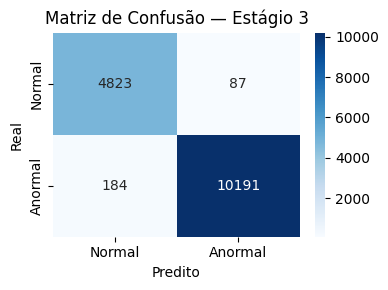

              precision    recall  f1-score   support

      Normal       0.96      0.98      0.97      4910
     Anormal       0.99      0.98      0.99     10375

    accuracy                           0.98     15285
   macro avg       0.98      0.98      0.98     15285
weighted avg       0.98      0.98      0.98     15285

AUC: 0.9956


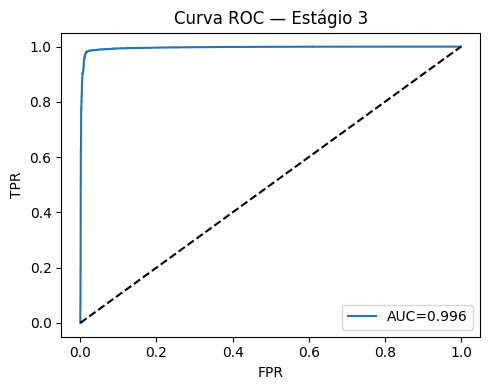

Sensitivity: 0.982 | Specificity: 0.982


In [19]:
# Avaliação — Estágio 3
y3_pred_proba = model3.predict(X3_test).flatten()
y3_pred = (y3_pred_proba >= 0.5).astype(int)

# Confusion Matrix
cm3 = confusion_matrix(y3_test, y3_pred)
fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm3, annot=True, fmt='d',
            xticklabels=['Normal', 'Anormal'],
            yticklabels=['Normal', 'Anormal'], cmap='Blues')
ax.set_xlabel('Predito'); ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão — Estágio 3')
plt.tight_layout(); plt.show()

print(classification_report(y3_test, y3_pred, target_names=['Normal', 'Anormal']))

if len(np.unique(y3_test)) == 2:
    auc3 = roc_auc_score(y3_test, y3_pred_proba)
    print(f"AUC: {auc3:.4f}")

    # Curva ROC
    fpr, tpr, _ = roc_curve(y3_test, y3_pred_proba)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f'AUC={auc3:.3f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('FPR'); plt.ylabel('TPR')
    plt.title('Curva ROC — Estágio 3')
    plt.legend(); plt.tight_layout(); plt.show()
else:
    auc3 = None
    print("AUC não calculada: o conjunto de teste possui apenas uma classe.")

tn, fp, fn, tp = cm3.ravel() if cm3.size == 4 else (0, 0, 0, 0)
sens = tp / (tp + fn) if (tp + fn) > 0 else 0
spec = tn / (tn + fp) if (tn + fp) > 0 else 0
print(f"Sensitivity: {sens:.3f} | Specificity: {spec:.3f}")


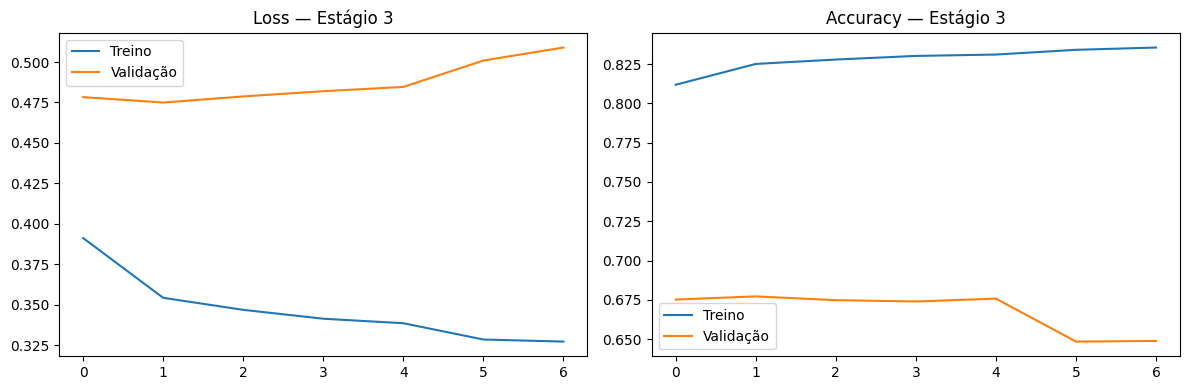

In [20]:
# Curvas de loss — Estágio 3
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history3.history['loss'], label='Treino')
axes[0].plot(history3.history['val_loss'], label='Validação')
axes[0].set_title('Loss — Estágio 3'); axes[0].legend()

axes[1].plot(history3.history['accuracy'], label='Treino')
axes[1].plot(history3.history['val_accuracy'], label='Validação')
axes[1].set_title('Accuracy — Estágio 3'); axes[1].legend()

plt.tight_layout(); plt.show()

Métricas por faixa de BPM:

--- alto_BPM_>100 | n=1032 ---
Distribuição y_true:
y_true
1    1032
Name: count, dtype: int64
Distribuição y_pred:
y_pred
1    1032
Name: count, dtype: int64
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00         0
     Anormal       1.00      1.00      1.00      1032

    accuracy                           1.00      1032
   macro avg       0.50      0.50      0.50      1032
weighted avg       1.00      1.00      1.00      1032


--- baixo_BPM_<60 | n=1911 ---
Distribuição y_true:
y_true
0    1452
1     459
Name: count, dtype: int64
Distribuição y_pred:
y_pred
0    1494
1     417
Name: count, dtype: int64
              precision    recall  f1-score   support

      Normal       0.95      0.98      0.97      1452
     Anormal       0.93      0.85      0.89       459

    accuracy                           0.95      1911
   macro avg       0.94      0.91      0.93      1911
weighted avg       0.95      0.95 

,mean,count,accuracy_percent
record_id,,,
01,0.977838,7400,97.78
100,0.986430,7885,98.64


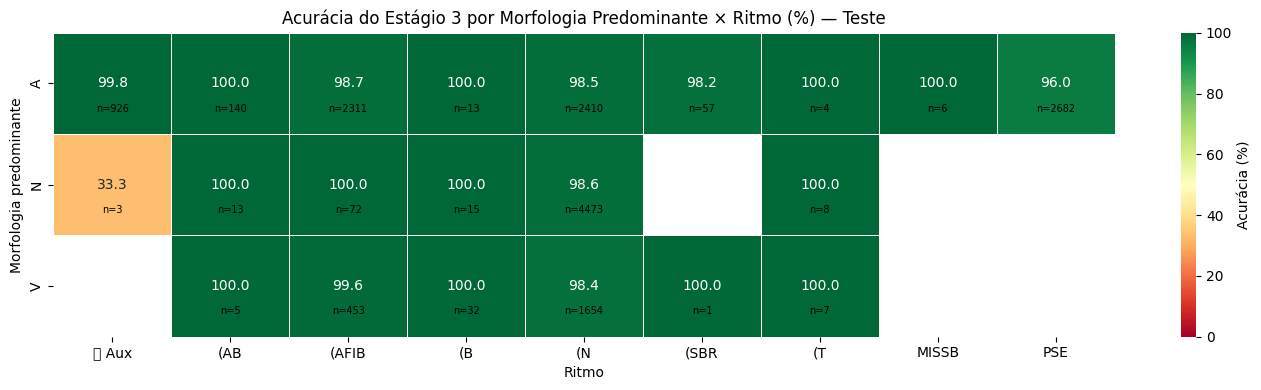

,bpm_group,accuracy_%,count
0,alto_BPM_>100,100.0,1032
1,baixo_BPM_<60,94.8,1911
2,normal_BPM_60_100,98.6,12342


In [23]:
# Análise do Estágio 3 por morfologia, ritmo, BPM e paciente/registro
df_test = window_df.loc[test_win_mask].copy().reset_index(drop=True)

df_test["y_pred_proba"] = y3_pred_proba
df_test["y_pred"] = y3_pred
df_test["correct"] = (df_test["y_true"] == df_test["y_pred"]).astype(int)

def bpm_group(mean_bpm):
    if mean_bpm < 60:
        return "baixo_BPM_<60"
    elif mean_bpm <= 100:
        return "normal_BPM_60_100"
    else:
        return "alto_BPM_>100"

df_test["bpm_group"] = df_test["mean_bpm"].apply(bpm_group)

# ------------------------------------------------------------
# Métricas por faixa de BPM
# ------------------------------------------------------------
print("Métricas por faixa de BPM:")

for group_name, group_df in df_test.groupby("bpm_group"):
    print(f"\n--- {group_name} | n={len(group_df)} ---")

    print("Distribuição y_true:")
    print(group_df["y_true"].value_counts().sort_index())

    print("Distribuição y_pred:")
    print(group_df["y_pred"].value_counts().sort_index())

    print(classification_report(
        group_df["y_true"],
        group_df["y_pred"],
        labels=[0, 1],
        target_names=["Normal", "Anormal"],
        zero_division=0
    ))

# ------------------------------------------------------------
# Acurácia por registro/paciente
# ------------------------------------------------------------
print("\nAcurácia por registro/paciente:")

display(
    df_test.groupby("record_id")["correct"]
    .agg(["mean", "count"])
    .assign(accuracy_percent=lambda x: (x["mean"] * 100).round(2))
    .sort_values("mean")
)

# ------------------------------------------------------------
# Heatmap: morfologia predominante x ritmo dominante
# ------------------------------------------------------------
pivot = (
    df_test
    .groupby(["dominant_morph", "dominant_rhythm"])["correct"]
    .agg(["mean", "count"])
    .reset_index()
)

pivot["mean"] = (pivot["mean"] * 100).round(1)

acc_matrix = pivot.pivot(
    index="dominant_morph",
    columns="dominant_rhythm",
    values="mean"
)

count_matrix = pivot.pivot(
    index="dominant_morph",
    columns="dominant_rhythm",
    values="count"
)

if acc_matrix.empty:
    print("Heatmap não gerado: não há dados suficientes para morfologia × ritmo.")
else:
    fig, ax = plt.subplots(figsize=(14, 4))

    sns.heatmap(
        acc_matrix,
        annot=True,
        fmt=".1f",
        cmap="RdYlGn",
        vmin=0,
        vmax=100,
        ax=ax,
        linewidths=0.5,
        cbar_kws={"label": "Acurácia (%)"}
    )

    for i in range(acc_matrix.shape[0]):
        for j in range(acc_matrix.shape[1]):
            val = count_matrix.iloc[i, j]
            if not np.isnan(val):
                ax.text(
                    j + 0.5,
                    i + 0.75,
                    f"n={int(val)}",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color="black"
                )

    ax.set_title("Acurácia do Estágio 3 por Morfologia Predominante × Ritmo (%) — Teste")
    ax.set_xlabel("Ritmo")
    ax.set_ylabel("Morfologia predominante")

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Resumo por faixa de BPM
# ------------------------------------------------------------
bpm_acc = (
    df_test
    .groupby("bpm_group")["correct"]
    .agg(["mean", "count"])
    .reset_index()
)

bpm_acc["accuracy_%"] = (bpm_acc["mean"] * 100).round(1)

display(
    bpm_acc[["bpm_group", "accuracy_%", "count"]]
    .sort_values("bpm_group")
)

In [24]:
# Salvamento do modelo de morfologia
os.makedirs("models", exist_ok=True)

MODEL2_PATH = "models/clean_model2_morphology.keras"
model2.save(MODEL2_PATH)

print(f"model2 salvo em: {MODEL2_PATH}")


model2 salvo em: models/clean_model2_morphology.keras


In [25]:
# Salvamento do modelo de ritmo
MODEL3_PATH = "models/clean_model3_rhythm.keras"
model3.save(MODEL3_PATH)

print(f"model3 salvo em: {MODEL3_PATH}")


model3 salvo em: models/clean_model3_rhythm.keras


In [26]:
# Salvamento de metadados necessários para inferência/reprodutibilidade
metadata = {
    "records": list(RECORDS),
    "failed_records": failed_records,
    "split_mode": split_mode,
    "train_records": list(map(str, train_records)),
    "val_records": list(map(str, val_records)),
    "test_records": list(map(str, test_records)),
    "target_len": TARGET_LEN,
    "window_sec": WINDOW_SEC,
    "max_beats": MAX_BEATS,
    "n_features_stage3": N_FEATURES,
    "morph_map": MORPH_MAP,
    "normal_ratio_threshold": NORMAL_RATIO_THRESHOLD,
    "stage2_classes": le2.classes_.tolist(),
    "stage3_feature_means": feature_means.flatten().tolist(),
    "stage3_feature_stds": feature_stds.flatten().tolist(),
    "bandpass": {
        "low": 0.5,
        "high": 40,
        "order": 3,
    },
}

with open("models/preprocessing_metadata.pkl", "wb") as f:
    pickle.dump(metadata, f)

with open("models/le2.pkl", "wb") as f:
    pickle.dump(le2, f)

print("Metadados salvos em: models/preprocessing_metadata.pkl")
print("LabelEncoder salvo em: models/le2.pkl")


Metadados salvos em: models/preprocessing_metadata.pkl
LabelEncoder salvo em: models/le2.pkl
